# Week 5 Deliverables - Bioinformatics Automatic Pipeline

## Task 0: Data Preparation - Download samples from Illumina and Pacbio sequencing
Download two given samples directly from URLs. One sample is from Illumina short reads, the other is from PacBio long reads

In [1]:
%%bash
wget -q https://github.com/inumanag/fall25-csc-bioinf/raw/refs/heads/main/week4/data/illumina.fq.bz2

wget -q https://github.com/inumanag/fall25-csc-bioinf/raw/refs/heads/main/week4/data/pacbio.fq.bz2

In [2]:
%%bash
# Unzip samples
bunzip2 illumina.fq.bz2
bunzip2 pacbio.fq.bz2

## Task 1: Download the human genome (hg38), chromosome 10
We want to analyze the following genes, which are responsible for drugs metabolism:
1. **CYP2C8** (regulates many drugs, including anticancer, diabetes and blood pressure drugs)
2. **CYP2C9** (regulates many common drugs, including warfarin / Coumadin and NSAIDs such as Advil)
3. **CYP2C19** (regulates many common drugs, including antiplatelet drugs, antidepressants and anti-epileptic drugs)

As all of these genes located in chromosome 10, we only need to download chr10.fa.gz from Genome Browser.

**URL**: https://genome.ucsc.edu/

In [3]:
%%bash
# Download chr10 from the hg38 human genome
wget -N "ftp://hgdownload.cse.ucsc.edu/goldenPath/hg38/chromosomes/chr10.fa.gz" -q -O chr10.fa.gz

# Uncompress the file
gunzip -f chr10.fa.gz

## Task 2:  Alignment using Minimap2
**Output**: Two BAM files and two BAI files (one for each sample)

#### Index the reference genome

In [5]:
!minimap2 -d ref.mmi chr10.fa
!samtools faidx chr10.fa

[M::mm_idx_gen::3.351*1.00] collected minimizers
[M::mm_idx_gen::3.790*1.22] sorted minimizers
[M::main::4.473*1.18] loaded/built the index for 1 target sequence(s)
[M::mm_idx_stat] kmer size: 15; skip: 10; is_hpc: 0; #seq: 1
[M::mm_idx_stat::4.617*1.18] distinct minimizers: 16061920 (79.91% are singletons); average occurrences: 1.563; average spacing: 5.329; total length: 133797422
[M::main] Version: 2.26-r1175
[M::main] CMD: minimap2 -d ref.mmi chr10.fa
[M::main] Real time: 4.643 sec; CPU: 5.467 sec; Peak RSS: 1.103 GB


#### Short-Read Illumina

In [6]:
%%bash
minimap2 -ax sr -t 4 ref.mmi illumina.fq > illumina_aligned.sam

# Convert SAM -> BAM -> Sorted BAM
samtools view -b illumina_aligned.sam > illumina_aligned.bam
samtools sort -o illumina_aligned_sorted.bam illumina_aligned.bam
samtools index illumina_aligned_sorted.bam # Index BAM file -> BAI file

[WARNING] Indexing parameters (-k, -w or -H) overridden by parameters used in the prebuilt index.
[M::main::0.866*1.00] loaded/built the index for 1 target sequence(s)
[M::mm_mapopt_update::0.866*1.00] mid_occ = 1000
[M::mm_idx_stat] kmer size: 15; skip: 10; is_hpc: 0; #seq: 1
[M::mm_idx_stat::0.998*1.00] distinct minimizers: 16061920 (79.91% are singletons); average occurrences: 1.563; average spacing: 5.329; total length: 133797422
[M::worker_pipeline::7.754*3.44] mapped 309505 sequences
[M::main] Version: 2.26-r1175
[M::main] CMD: minimap2 -ax sr -t 4 ref.mmi illumina.fq
[M::main] Real time: 7.766 sec; CPU: 26.722 sec; Peak RSS: 0.925 GB


#### Long-Read PacBio

In [7]:
%%bash
minimap2 -ax map-pb -t 4 ref.mmi pacbio.fq > pacbio_aligned.sam

# Convert SAM -> BAM -> Sorted BAM
samtools view -b pacbio_aligned.sam > pacbio_aligned.bam
samtools sort -o pacbio_aligned_sorted.bam pacbio_aligned.bam
samtools index pacbio_aligned_sorted.bam # Index BAM file -> BAI file

[WARNING] Indexing parameters (-k, -w or -H) overridden by parameters used in the prebuilt index.
[M::main::1.069*0.98] loaded/built the index for 1 target sequence(s)
[M::mm_mapopt_update::1.291*0.98] mid_occ = 178
[M::mm_idx_stat] kmer size: 15; skip: 10; is_hpc: 0; #seq: 1
[M::mm_idx_stat::1.426*0.98] distinct minimizers: 16061920 (79.91% are singletons); average occurrences: 1.563; average spacing: 5.329; total length: 133797422
[M::worker_pipeline::2.316*2.06] mapped 3063 sequences
[M::main] Version: 2.26-r1175
[M::main] CMD: minimap2 -ax map-pb -t 4 ref.mmi pacbio.fq
[M::main] Real time: 2.328 sec; CPU: 4.794 sec; Peak RSS: 0.748 GB


## Task 3: Variants Calling using BCFTools
Call variants for the interested genes - **CYP2C8, CYP2C9, and CYP2C19**

**Input**: sorted BAM file for each sample

**Output**: VCF file for each sample

#### Short-Read Illumina

In [8]:
%%bash
# Set positions for the interested genes
REGIONS="chr10:95036772-95069497,chr10:94938658-94990091,chr10:94762681-94855547"

# Create BCF from mpileup
bcftools mpileup -Ou -f chr10.fa -r "$REGIONS" illumina_aligned_sorted.bam \
| bcftools call -mv -Ov -o illumina_variants.vcf

Note: none of --samples-file, --ploidy or --ploidy-file given, assuming all sites are diploid
[mpileup] 1 samples in 1 input files
[mpileup] maximum number of reads per input file set to -d 250


#### Long-Read PacBio

In [9]:
%%bash
# Set positions for the interested genes
REGIONS="chr10:95036772-95069497,chr10:94938658-94990091,chr10:94762681-94855547"

bcftools mpileup -Ou -f chr10.fa -r "$REGIONS" pacbio_aligned_sorted.bam \
| bcftools call -mv -Ov -o pacbio_variants.vcf

Note: none of --samples-file, --ploidy or --ploidy-file given, assuming all sites are diploid
[mpileup] 1 samples in 1 input files
[mpileup] maximum number of reads per input file set to -d 250


## Task 4: Phase the Variant VCFs with HapCUT2
**Output**: Two VCF files (one for each sample)

#### Sort Variant Files

In [6]:
%%bash
# Illumina
bcftools sort -T tmp_il -O v -o illumina_variants.sorted.vcf illumina_variants.vcf

# PacBio
bcftools sort -T tmp_pb -O v -o pacbio_variants.sorted.vcf pacbio_variants.vcf

Writing to tmp_ilmc5q3K
Merging 1 temporary files
Cleaning
Done
Writing to tmp_pbI0xKQh
Merging 1 temporary files
Cleaning
Done


#### Short-Read Illumina

In [13]:
%%bash
# Convert BAM file to the compact fragment file format containing only haplotype-relevant information
extractHAIRS \
  --bam illumina_aligned_sorted.bam \
  --VCF illumina_variants.sorted.vcf \
  --out illumina_fragment_file \
  --ref chr10.fa \
  --mbq 10 --mmq 15 --maxIS 1500

HAPCUT2 \
  --fragments illumina_fragment_file \
  --vcf illumina_variants.sorted.vcf \
  --output illumina_haplotype_output


Extracting haplotype informative reads from bamfiles illumina_aligned_sorted.bam minQV 10 minMQ 15 maxIS 1500 

VCF file illumina_variants.sorted.vcf has 296 variants 
adding chrom chr10 to index 
vcffile illumina_variants.sorted.vcf chromosomes 1 hetvariants 175 variants 296 
detected 4 variants with two non-reference alleles, these variants will not be phased
reading fasta index file chr10.fa.fai ... fasta file chr10.fa has 1 chromosomes/contigs

found match for reference contig chr10 in VCF file index 
contig chr10 length 133797422
reading reference sequence file chr10.fa with 1 contigs
read reference sequence file in 0.25 sec
reading sorted bam/cram file illumina_aligned_sorted.bam 
processing reads mapped to chrom "chr10" 
final cleanup of fragment list: 5986 current chrom 0 prev 0 


#### Long-Read PacBio

In [14]:
%%bash
extractHAIRS \
  --pacbio 1 \
  --bam pacbio_aligned_sorted.bam \
  --VCF pacbio_variants.sorted.vcf \
  --out pacbio_fragment_file \
  --ref chr10.fa

HAPCUT2 \
  --fragments pacbio_fragment_file \
  --vcf pacbio_variants.sorted.vcf \
  --output pacbio_haplotype_output


Extracting haplotype informative reads from bamfiles pacbio_aligned_sorted.bam minQV 4 minMQ 20 maxIS 1000 

VCF file pacbio_variants.sorted.vcf has 329 variants 
adding chrom chr10 to index 
vcffile pacbio_variants.sorted.vcf chromosomes 1 hetvariants 203 variants 329 
detected 7 variants with two non-reference alleles, these variants will not be phased
reading fasta index file chr10.fa.fai ... fasta file chr10.fa has 1 chromosomes/contigs

found match for reference contig chr10 in VCF file index 
contig chr10 length 133797422
reading reference sequence file chr10.fa with 1 contigs
read reference sequence file in 0.25 sec
reading sorted bam/cram file pacbio_aligned_sorted.bam 
using 3063 reads to estimate realignment parameters for HMM 
A -> A 0.9990 0.998978 | A -> C 0.0001 0.000138 | A -> G 0.0006 0.000628 | A -> T 0.0003 0.000258 | 
C -> A 0.0003 0.000255 | C -> C 0.9982 0.998151 | C -> G 0.0002 0.000240 | C -> T 0.0014 0.001356 | 
G -> A 0.0014 0.001386 | G -> C 0.0002 0.000232 |

## Task 5: Automatic Variants Visualization

#### Normalize, Split, and Sort Multi-Allelic

In [15]:
%%bash
# Normalizing & Splitting - one ALT per row, left-align to ref for fair comparison
bcftools norm -f chr10.fa -m -both -Ov -o illumina.norm.vcf illumina_haplotype_output.phased.VCF
bcftools norm -f chr10.fa -m -both -Ov -o pacbio.norm.vcf pacbio_haplotype_output.phased.VCF

# Sorting and Indexing
bcftools sort -Oz -o illumina_phased.sorted.vcf.gz illumina.norm.vcf
bcftools sort -Oz -o pacbio_phased.sorted.vcf.gz  pacbio.norm.vcf
bcftools index -t illumina_phased.sorted.vcf.gz 
bcftools index -t pacbio_phased.sorted.vcf.gz

# Identify Common and Uncommon Variants
bcftools isec illumina_phased.sorted.vcf.gz pacbio_phased.sorted.vcf.gz -p isec_output

#### Identify Common and Unique Variants between Two Sequencing Technologies

In [16]:
import subprocess

def count_variants(path):
    result = subprocess.run(f"grep -vc '^#' {path}", shell=True, capture_output=True, text=True)
    return int(result.stdout.strip())

illumina = count_variants("isec_output/0000.vcf")
pacbio   = count_variants("isec_output/0001.vcf")
common   = count_variants("isec_output/0002.vcf")
uncommon = illumina + pacbio

print(f"Number of common variants: {common}")
print(f"Number of uncommon variants: {uncommon}")
print(f"Number of Illumina-only variants: {illumina}")
print(f"Number of PacBio-only variants: {pacbio}")

Number of common variants: 280
Number of uncommon variants: 76
Number of Illumina-only variants: 20
Number of PacBio-only variants: 56


#### Extract Three Variants for Each Gene

In [17]:
%%bash
# Inputs: phased/sorted VCFs (bgzip and indexed)
ILLUMINA="isec_output/0000.vcf"
PACBIO="isec_output/0001.vcf"

# Gene List (CHR START END NAME)
read -r -d '' GENES <<'EOF'
chr10 95036772 95069497 GENE_CYP2C8
chr10 94938658 94990091 GENE_CYP2C9
chr10 94762681 94855547 GENE_CYP2C19
EOF

# Output Files
: > illumina_loci.txt
: > pacbio_loci.txt

# Create a helper function to extract 3 variants per gene
extract_var() {
    local vcf="$1" chr="$2" start="$3" end="$4" n="$5"
    awk -v c="$chr" -v s="$start" -v e="$end" '
        $0 !~ /^#/ && $1==c && $2>=s && $2<=e { print $1 ":" $2 "\t" $4 ">" $5 }
    ' "$vcf" | awk '!seen[$1]++' | head -"$n"
}

# Extract three variants per gene for each sequencing technology
while read -r CHR START END NAME; do
  # Illumina:
    extract_var "$ILLUMINA" "$CHR" "$START" "$END" 3 \
  | awk -v g="$NAME" '{print g "\t" $0}' >> illumina_loci.txt

  # PacBio
    extract_var "$PACBIO" "$CHR" "$START" "$END" 3 \
  | awk -v g="$NAME" '{print g "\t" $0}' >> pacbio_loci.txt
done <<< "$GENES"

##### Read and Print out the selected variants

In [23]:
il_file_path = "illumina_loci.txt"
pb_file_path = "pacbio_loci.txt"

print("Selected Variants from Illumina:")
try:
    with open(il_file_path, 'r', encoding='utf-8') as file:
        il_var = file.read()
        print(il_var)
except FileNotFoundError:
    print(f"Error: The file '{il_file_path}' was not found.")
except Exception as e:
    print(f"An error occurred: {e}")

print("Selected Variants from PacBio:")
try:
    with open(pb_file_path, 'r', encoding='utf-8') as file:
        pb_var = file.read()
        print(pb_var)
except FileNotFoundError:
    print(f"Error: The file '{pb_file_path}' was not found.")
except Exception as e:
    print(f"An error occurred: {e}")

Selected Variants from Illumina:
GENE_CYP2C8	chr10:95046748	TAA>T
GENE_CYP2C8	chr10:95069062	CA>C
GENE_CYP2C9	chr10:94969284	A>C
GENE_CYP2C9	chr10:94974535	G>GTTTT
GENE_CYP2C19	chr10:94772788	G>T
GENE_CYP2C19	chr10:94772850	T>C
GENE_CYP2C19	chr10:94772907	G>A

Selected Variants from PacBio:
GENE_CYP2C8	chr10:95046748	TAAA>T
GENE_CYP2C8	chr10:95049946	AG>A
GENE_CYP2C8	chr10:95049952	G>A
GENE_CYP2C9	chr10:94941267	G>GTT
GENE_CYP2C9	chr10:94947469	T>C
GENE_CYP2C9	chr10:94952992	G>A
GENE_CYP2C19	chr10:94770084	C>T
GENE_CYP2C19	chr10:94770332	G>A
GENE_CYP2C19	chr10:94773525	A>G



#### Create Batch File to Take Screenshots automatically

In [9]:
%%bash
{
  echo "new"
  echo "genome $HOME/chr10.fa"

  # Load tracks
  echo "load $HOME/illumina_aligned_sorted.bam"
  echo "load $HOME/pacbio_aligned_sorted.bam"
  echo "load $HOME/illumina_phased.sorted.vcf.gz"
  echo "load $HOME/pacbio_phased.sorted.vcf.gz"

  # Set display preferences
  echo "preference SAM.SHOW_SOFT_CLIPPED true"
  echo "preference SAM.SHOW_CENTER_LINE true"
  echo "preference SAM.COLOR_BY READ_STRAND"
  echo "maxPanelHeight 1800"

  # -------- Illumina -------- #
  echo "snapshotDirectory $HOME"
  while IFS=$'\t' read -r GENE LOC REFALT; do
    LOC_SAFE="${LOC/:/_}"
    echo "goto $LOC"
    echo "expand"
    echo "sort base"
    echo "snapshot \"${GENE}_${LOC_SAFE}_illumina.png\""
  done < $HOME/illumina_loci.txt

  # -------- PacBio -------- #
  echo "snapshotDirectory $HOME"
  while IFS=$'\t' read -r GENE LOC REFALT; do
    LOC_SAFE="${LOC/:/_}"
    echo "goto $LOC"
    echo "expand"
    echo "sort base"
    echo "snapshot \"${GENE}_${LOC_SAFE}_pacbio.png\""
  done < $HOME/pacbio_loci.txt

  echo "exit"
} > $HOME/batch.txt

#### Take Screenshots of Variants on IGV Automatically
**Output**: PNG images of variants. The screenshots are stored in 'screenshot' folder.

In [10]:
%%bash
export LIBGL_ALWAYS_SOFTWARE=1
export IGV_JAVA_OPTS="-Djava.awt.headless=false -Dsun.java2d.xrender=false"
IGV="$HOME/IGV_2.19.7/igv.sh"

mkdir -p $HOME
pkill -f igv.sh 2>/dev/null || true

xvfb-run -a --server-args="-screen 0 1920x1080x24 -ac +render -noreset" \
  env IGV_JAVA_OPTS="$IGV_JAVA_OPTS" \
  "$IGV" -p 0 -b "$HOME/batch.txt" > igv.log 2>&1 &

#### Display the Screenshots for Illumina

GENE_CYP2C8_chr10_95046748_illumina.png


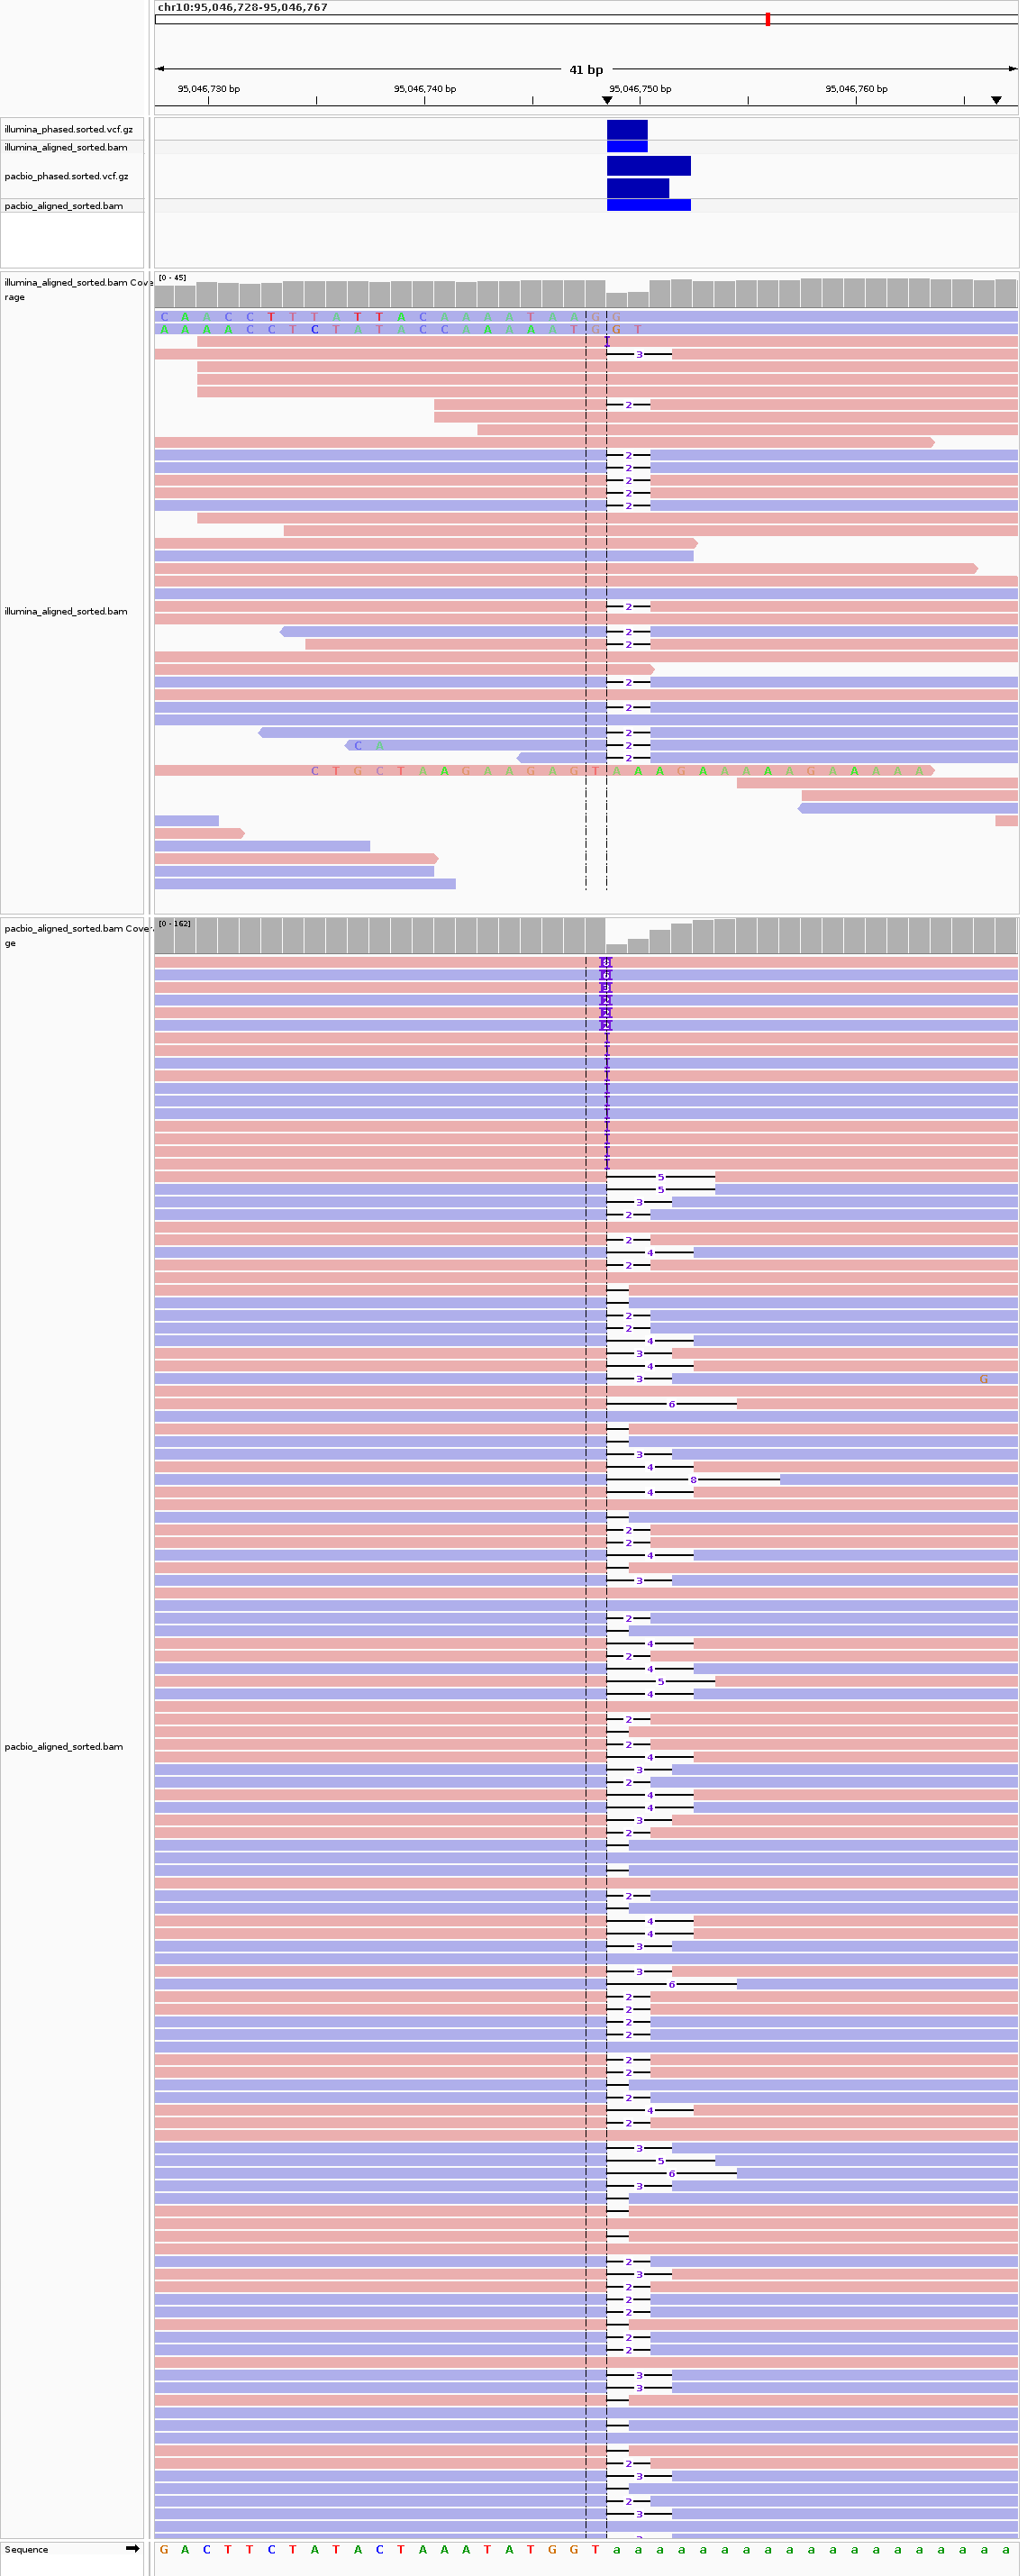

GENE_CYP2C8_chr10_95069062_illumina.png


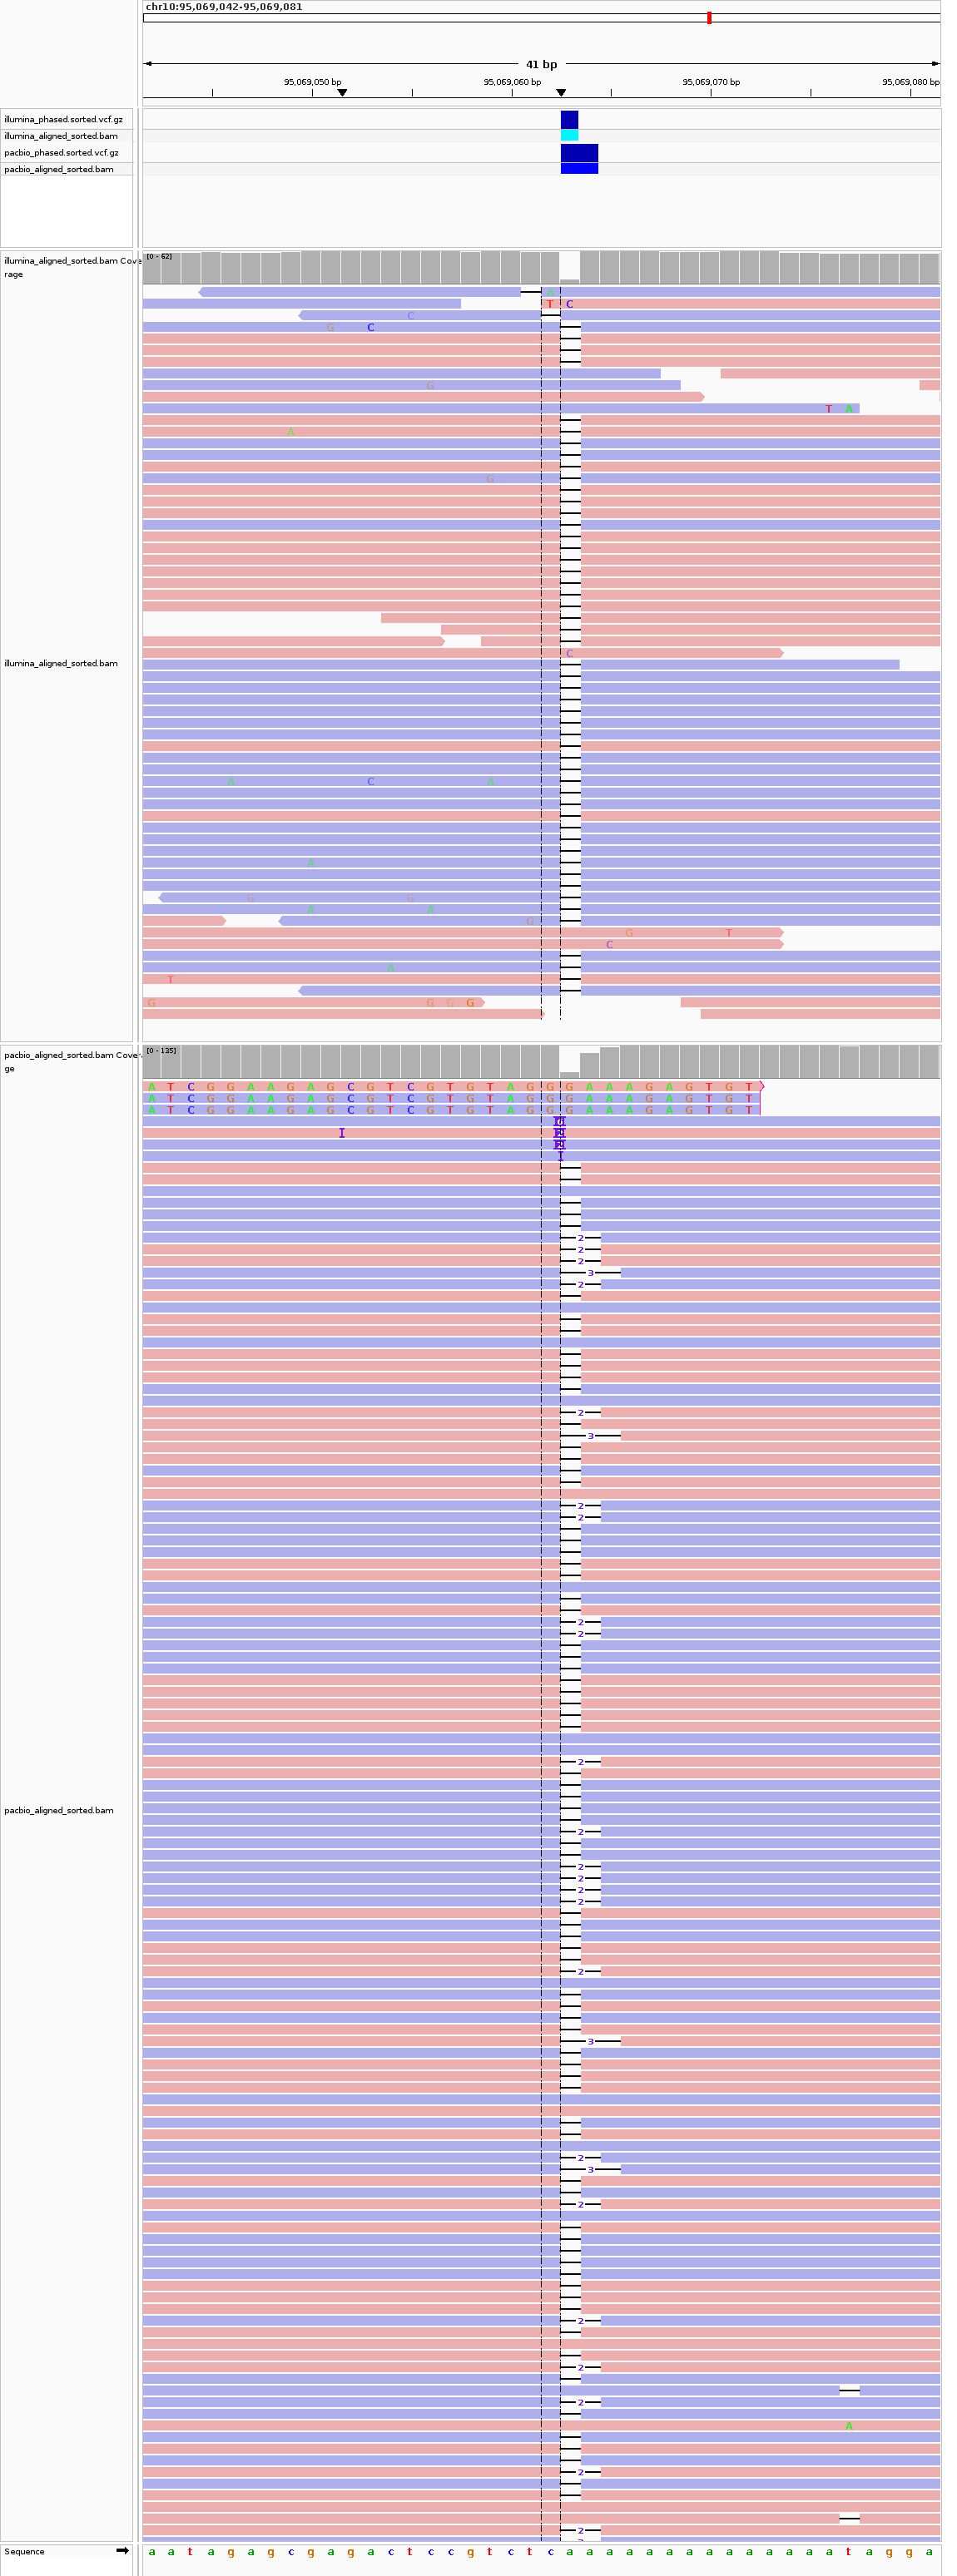

GENE_CYP2C9_chr10_94969284_illumina.png


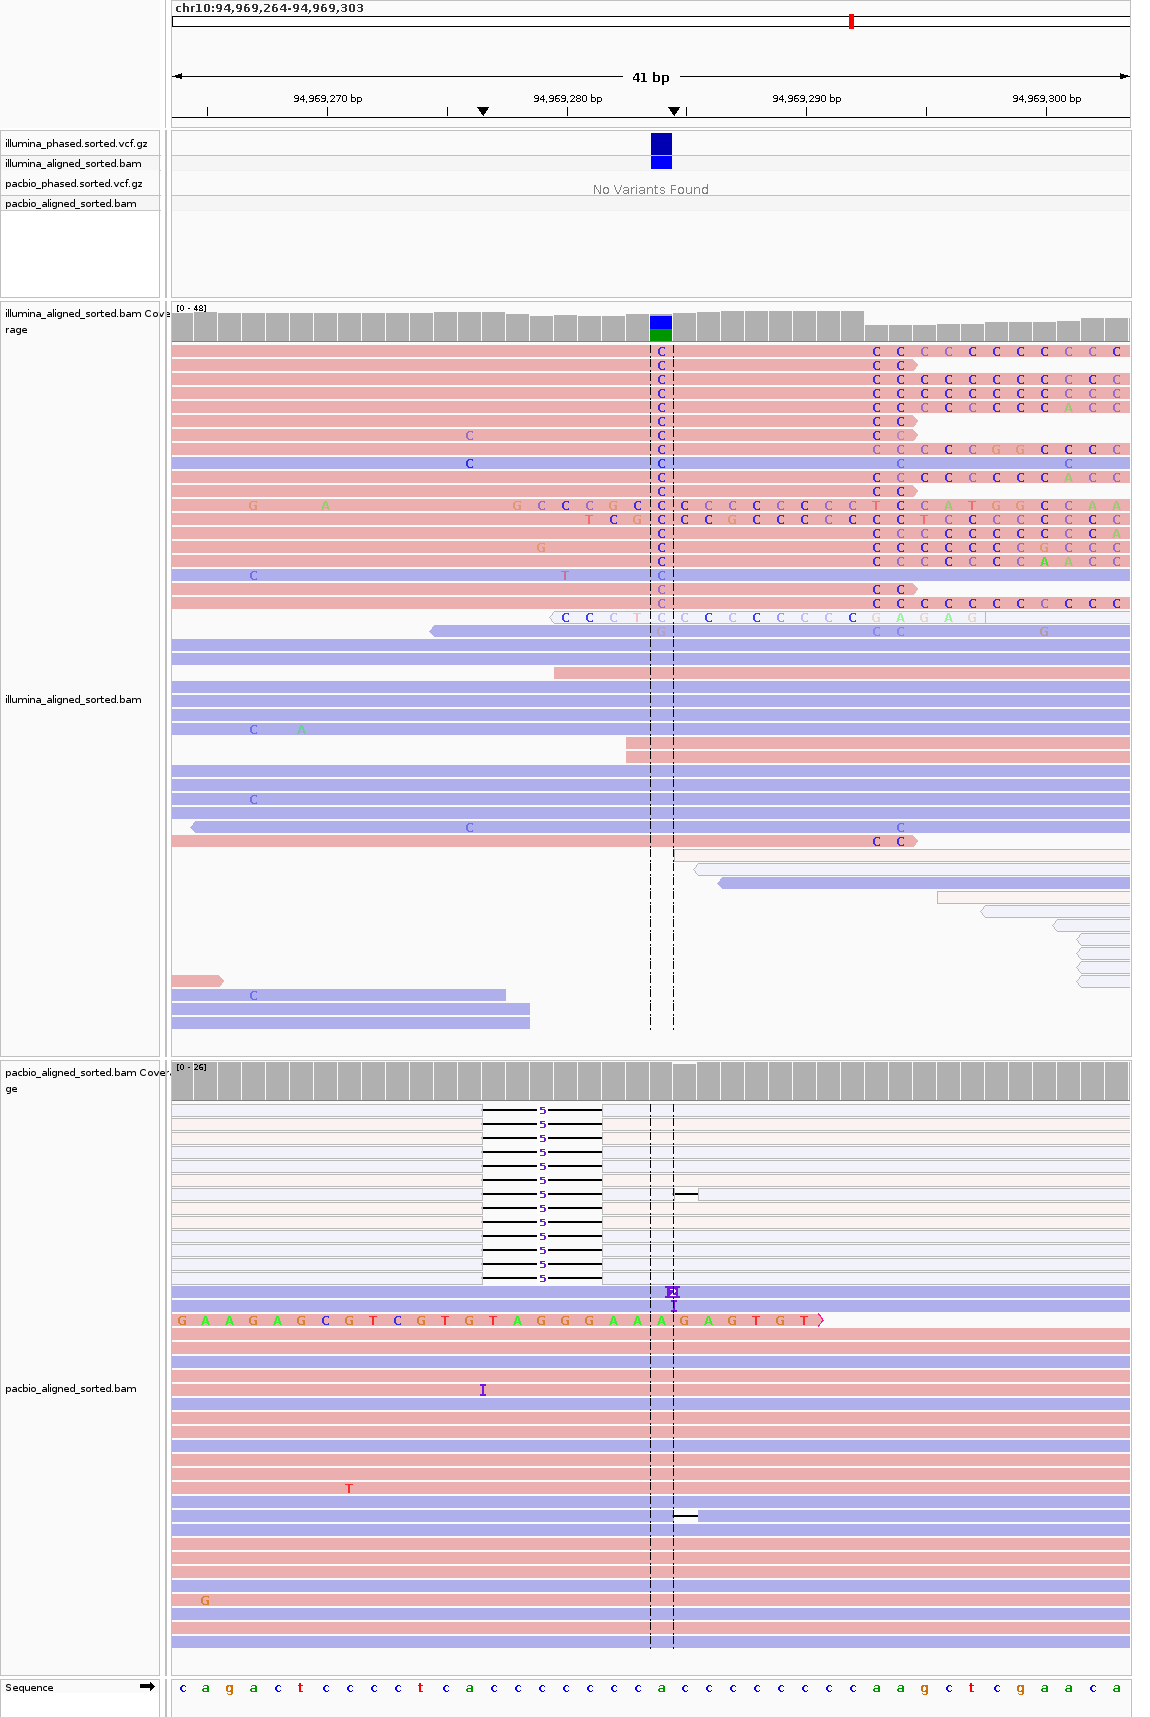

GENE_CYP2C9_chr10_94974535_illumina.png


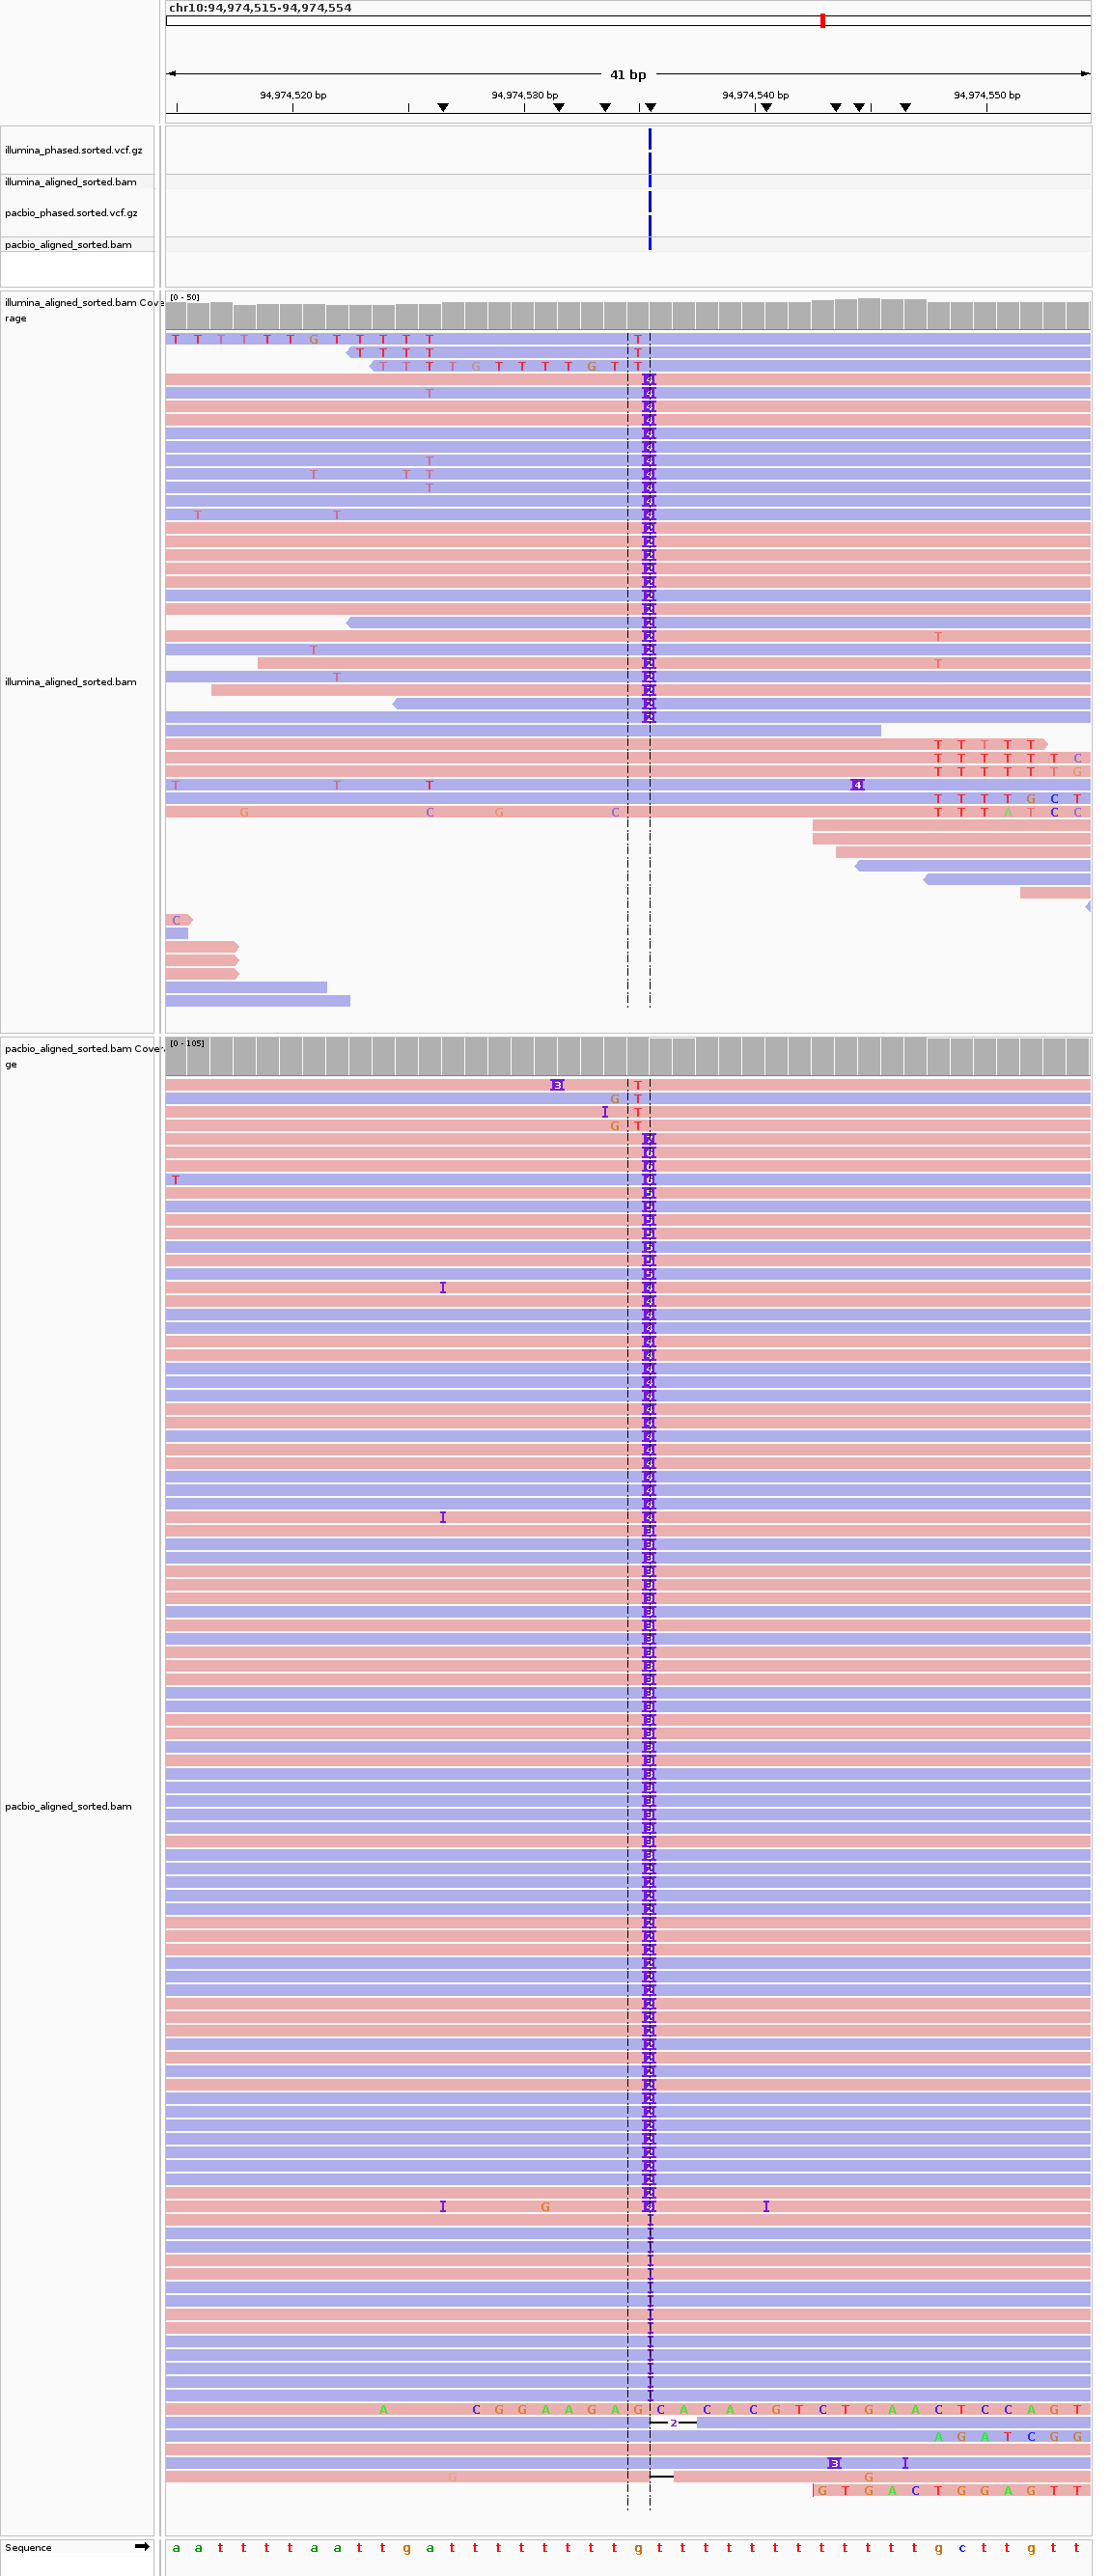

GENE_CYP2C19_chr10_94772788_illumina.png


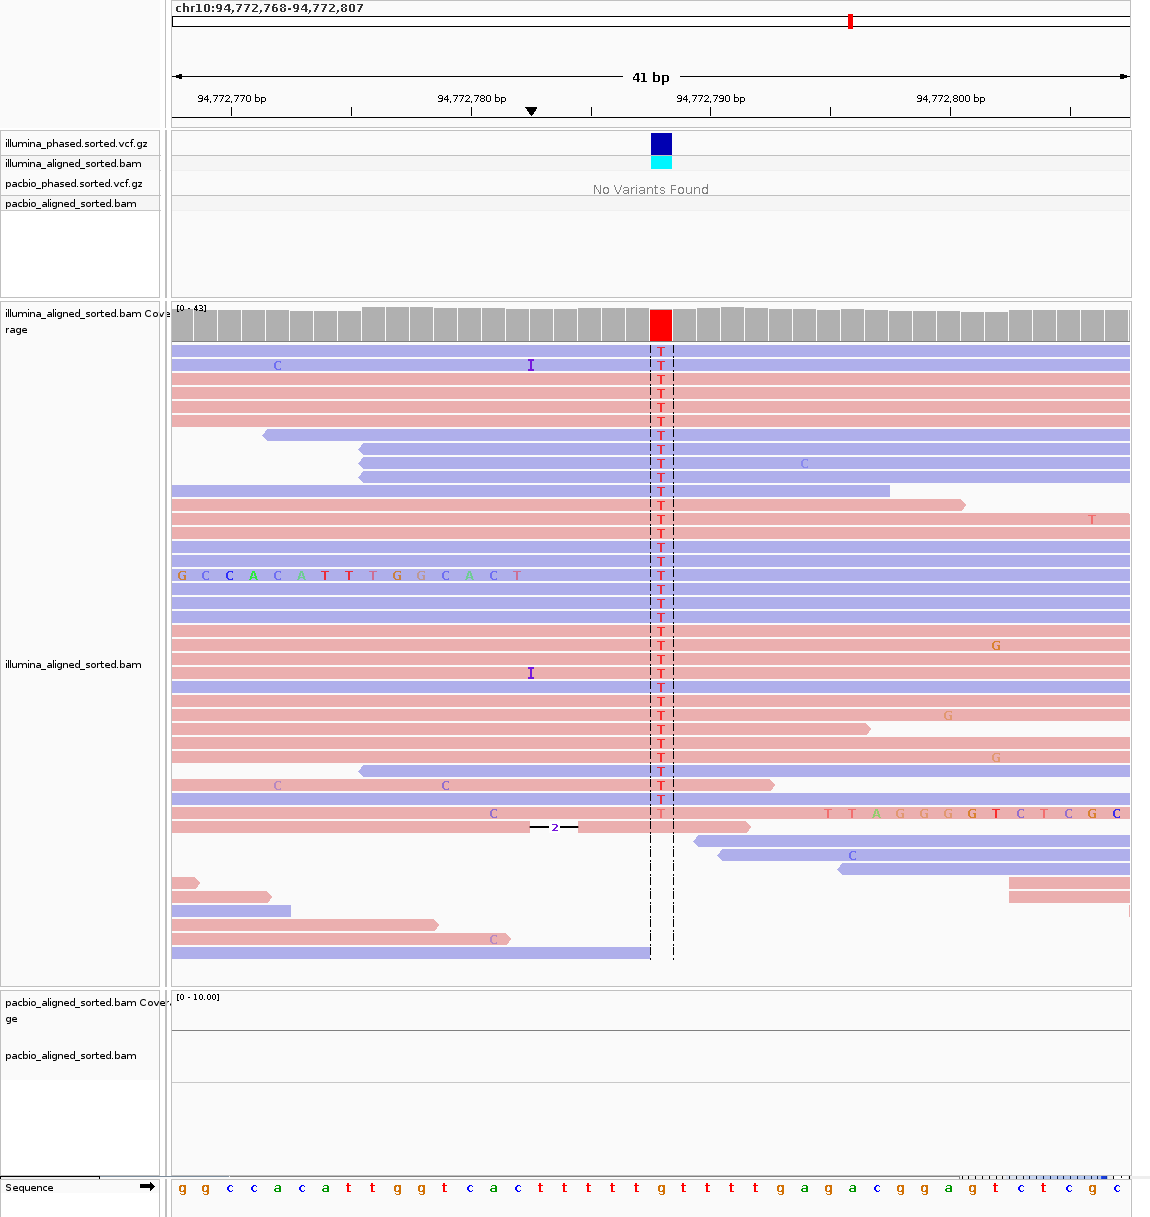

GENE_CYP2C19_chr10_94772850_illumina.png


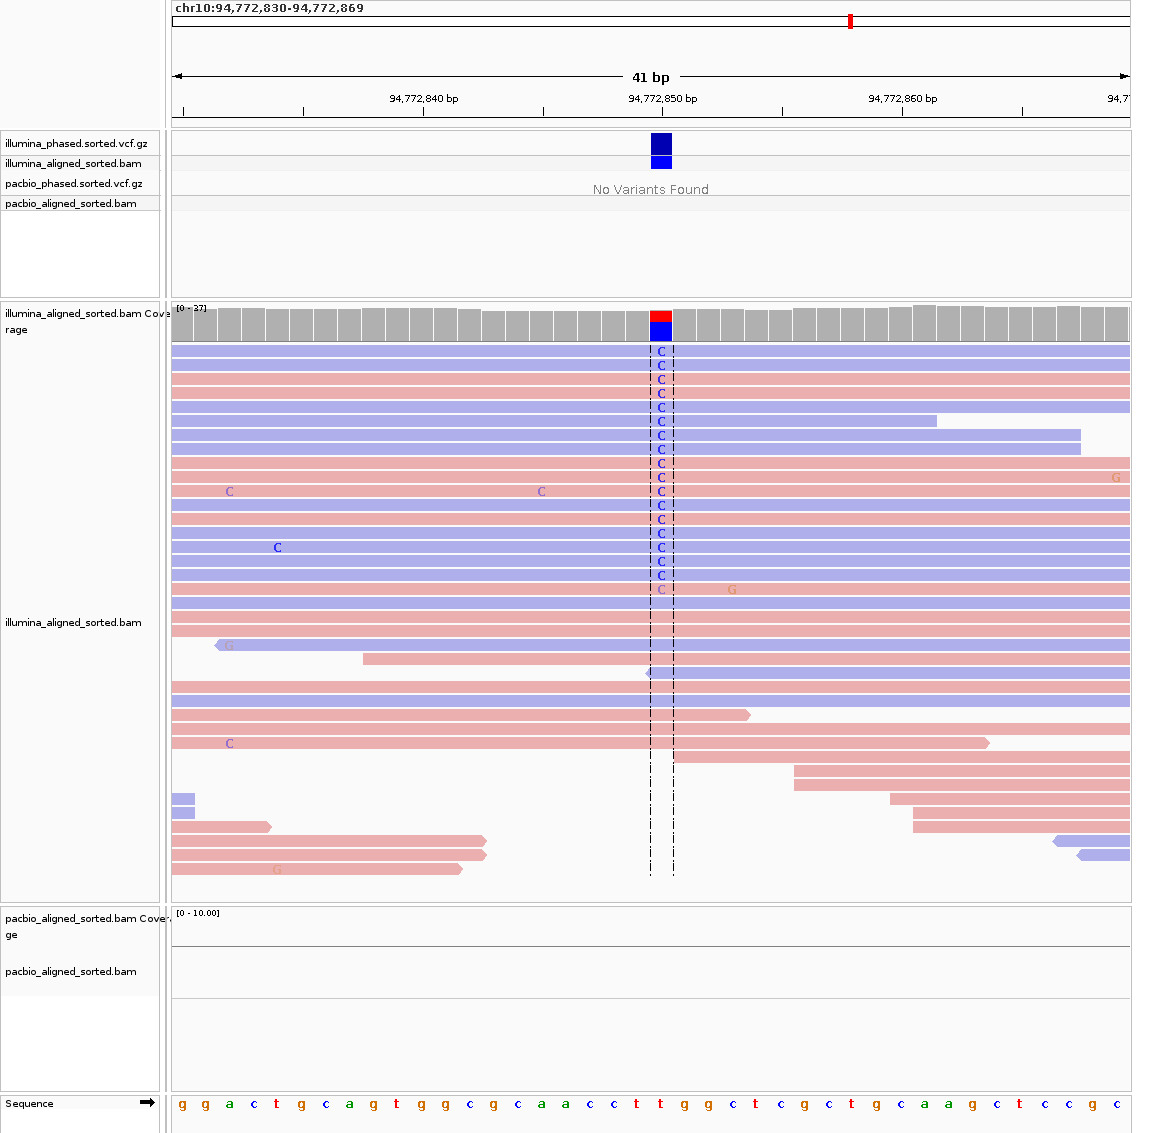

GENE_CYP2C19_chr10_94772907_illumina.png


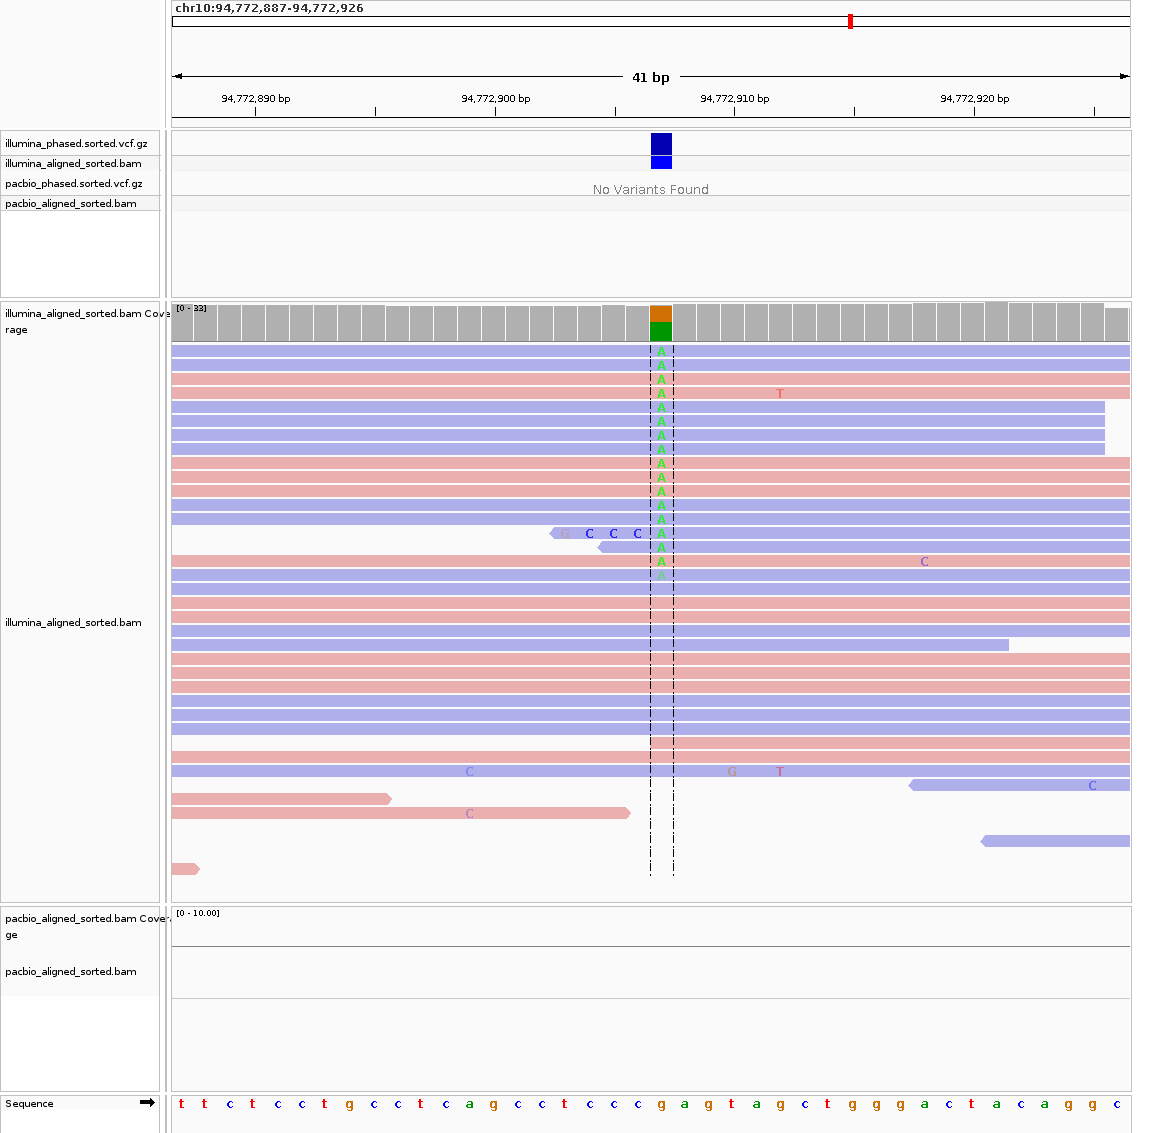

In [14]:
from IPython.display import Image, display
import os

snapdir = os.path.expanduser

il_file_path = "illumina_loci.txt"

file_path = []
il_var = ""

try:
    with open(il_file_path, 'r', encoding='utf-8') as file:
        il_var = file.read()
except FileNotFoundError:
    print(f"Error: The file '{il_file_path}' was not found.")
except Exception as e:
    print(f"An error occurred: {e}")
    
for var in il_var.splitlines():
    var = var.strip()
    if not var:
        continue
        
    gene, locus, change = var.split()
    locus = locus.replace(":", "_")
    
    file_name = f"{gene}_{locus}_illumina.png"
    
    print(file_name)
    display(Image(file_name))

#### Display the Screenshots for PacBio

In [ ]:
%%bash
import os
from IPython.display import Image, display

snapdir = os.path.expanduser("~")

pb_file_path = "pacbio_loci.txt"

file_path = []
pb_var = ""

try:
    with open(pb_file_path, 'r', encoding='utf-8') as file:
        pb_var = file.read()
except FileNotFoundError:
    print(f"Error: The file '{pb_file_path}' was not found.")
except Exception as e:
    print(f"An error occurred: {e}")

for var in pb_var.splitlines():
    var = var.strip()
    if not var:
        continue
        
    gene, locus, change = var.split()
    locus = locus.replace(":", "_")
    
    file_name = f"{gene}_{locus}_pacbio.png"
    file_path = os.path.join(snapdir, file_name)
    print(file_name)
    display(Image(filename=str(file_path)))

#### Discussion
##### Illumina
1. GENE_CYP2C8	chr10:95046748: More than half of the reads supported this 2bp deletion. Additionally, PacBio sequencing technology also agrees on this variant. Hence, it's likely to be a true variant.
2. GENE_CYP2C8	chr10:95069062: It's likely to be a true variant because most of the reads support this deletion. The variant is also supported by PacBio. 
3. GENE_CYP2C9	chr10:94969284: Variant appears to be on only the read strands -> could be artifact. 
4. GENE_CYP2C9	chr10:94974535: The variant is supported by both Illumina and PacBio, with most reads agree with the insertion. Hence, it seems to be a true variant.
5. GENE_CYP2C19	chr10:94772788: This variant seems to be just an artifact - difference in lower and upper t - T.
6. GENE_CYP2C19	chr10:94772850: This seems to be a heterozygous variant, with half the reads support the reference and the other half support the allele.
7. GENE_CYP2C19	chr10:94772907: Same as above.

##### PacBio
1. GENE_CYP2C8	chr10:95046748: The read coverage here is surprisingly lower than its adjacent areas (sudden drop from the left and slowly rise back on the right). Hence, it's likely to be a true deletion. Most reads also agree with this deletion.
2. GENE_CYP2C8	chr10:95049946: Most reads agree with the deletion at this position. Hence, it's likely to be a true variant.
3. GENE_CYP2C8	chr10:95049952: This seems to be a heterozygous variant, with one allele has the reference base (G), the other allele has the alternate base (A).
4. GENE_CYP2C9	chr10:94941267: The variant here seems to be supported by only PacBio. Alignment around this position is quite poor, with various number of insertions. It's likely to be a sequencing artifact.
5. GENE_CYP2C9	chr10:94947469: Only a few reads (and only PacBio) support this variant, which is mostly located on the blue strands. Hence, it's a sequencing artifact.
6. GENE_CYP2C9	chr10:94952992: Only a few reads support this -> most likely artifact.
7. GENE_CYP2C19	chr10:94770084: Seems to be an artifact.
8. GENE_CYP2C19	chr10:94770332: Seems to be an artifact.
9. GENE_CYP2C19	chr10:94773525: Most reads agree with the reference. Seems to be an artifact.

## Task 6: Identify Star-Allele

##### Gene CYP2C8

In [24]:
print("Illumina Variants")
!bcftools view -r chr10:95036772-95069497 illumina_phased.sorted.vcf.gz \
  | bcftools query -f '%CHROM\t%POS\t%REF\t%ALT\t[%GT]\n'

print("\nPacBio Variants")
!bcftools view -r chr10:95036772-95069497 pacbio_phased.sorted.vcf.gz \
  | bcftools query -f '%CHROM\t%POS\t%REF\t%ALT\t[%GT]\n'


Illumina Variants
chr10	95037104	G	A	1|0
chr10	95037401	C	T	1|0
chr10	95037713	C	T	1/1
chr10	95038791	C	T	1|0
chr10	95039254	G	A	0|1
chr10	95039931	C	G	1/1
chr10	95040597	T	C	1/1
chr10	95041625	C	CA	0/1
chr10	95041650	G	A	0|1
chr10	95041674	G	T	1|0
chr10	95041676	G	A	1|0
chr10	95041706	G	C	1|0
chr10	95041787	CAAAA	C	0/1
chr10	95041787	CAAAAA	C	1/0
chr10	95041996	C	T	1/1
chr10	95042048	T	A	1/1
chr10	95042106	C	T	1/1
chr10	95042403	TA	T	1/1
chr10	95042841	A	T	1/1
chr10	95043407	A	C	1|0
chr10	95043864	G	GCA	0/1
chr10	95043864	G	GCACA	1/0
chr10	95043892	A	G	0|1
chr10	95044694	C	T	1/1
chr10	95045154	G	A	1/1
chr10	95045221	G	A	1/1
chr10	95045303	A	G	0/1
chr10	95045614	C	T	1/1
chr10	95046431	TG	T	1/1
chr10	95046748	TAA	T	0/1
chr10	95048734	T	C	1/1
chr10	95048853	T	C	1/1
chr10	95049619	T	A	1/1
chr10	95050580	C	A	1/1
chr10	95050795	T	C	1/1
chr10	95050855	C	T	1/1
chr10	95051253	T	C	1/1
chr10	95051288	G	C	1/1
chr10	95051468	C	T	1/1
chr10	95052084	A	G	1/1
chr10	95053039	ac	a	1/1
chr10	95053086	G	A

**CYP2C8*2 (0|1)** because the variant at position 95058349 is A, while reference is T. This variant is supported by both short- and long-reads.

##### Gene CYP2C9

In [25]:
print("Illumina Variants")
!bcftools view -r chr10:94938658-94990091 illumina_phased.sorted.vcf.gz \
  | bcftools query -f '%CHROM\t%POS\t%REF\t%ALT\t[%GT]\n'

print("\nPacBio Variants")
!bcftools view -r chr10:94938658-94990091 pacbio_phased.sorted.vcf.gz \
  | bcftools query -f '%CHROM\t%POS\t%REF\t%ALT\t[%GT]\n'

Illumina Variants
chr10	94938933	T	C	0/1
chr10	94939926	G	A	0/1
chr10	94940780	C	T	1/1
chr10	94940873	A	T	1/1
chr10	94941320	G	T	0/1
chr10	94942093	T	C	0/1
chr10	94943734	C	A	0/1
chr10	94944819	A	G	1/1
chr10	94945466	A	T	0/1
chr10	94946130	T	C	1|0
chr10	94946131	G	T	1|0
chr10	94946177	A	G	1/1
chr10	94946652	C	G	0/1
chr10	94950236	T	C	1/1
chr10	94950968	C	T	1/1
chr10	94952127	G	A	1|0
chr10	94952386	T	C	0|1
chr10	94952643	A	G	1/1
chr10	94952785	T	TATAG	0/1
chr10	94953443	T	C	0/1
chr10	94954003	G	A	0/1
chr10	94955914	T	C	1|0
chr10	94956377	C	T	1|0
chr10	94956617	A	C	1|0
chr10	94957439	T	G	1/1
chr10	94958456	T	C	0|1
chr10	94959037	C	T	0|1
chr10	94959052	G	T	1|0
chr10	94959431	A	G	1/1
chr10	94959719	A	G	1/1
chr10	94960070	A	G	1/1
chr10	94960275	T	C	1/1
chr10	94960761	A	G	0/1
chr10	94961350	G	C	1/1
chr10	94962302	C	A	1/1
chr10	94963667	A	G	0/1
chr10	94964413	T	C	1/1
chr10	94966538	TC	T	0/1
chr10	94967800	G	A	1|0
chr10	94968273	C	T	1|0
chr10	94968463	A	C	1|0
chr10	94968568	T	G	1|0
chr10	94968

**CYP2C9*5** because the variant at position 94981301 is C, while reference is G. This variant is supported by both short- and long-reads. Hence, this person's gene CYP2C9 has intermediate decreased function (1|0).

##### Gene CYP2C19

In [238]:
print("Illumina Variants")
!bcftools view -r chr10:94762681-94855547 illumina_phased.sorted.vcf.gz \
  | bcftools query -f '%CHROM\t%POS\t%REF\t%ALT\t[%GT]\n'

print("\nPacBio Variants")
!bcftools view -r chr10:94762681-94855547 pacbio_phased.sorted.vcf.gz \
  | bcftools query -f '%CHROM\t%POS\t%REF\t%ALT\t[%GT]\n'

Illumina Variants
chr10	94762804	C	T	1/1
chr10	94763232	A	T	0/1
chr10	94765362	G	A	0/1
chr10	94765779	G	A	1/1
chr10	94766304	T	TTGTA	1/1
chr10	94766352	G	A	0/1
chr10	94767381	A	C	1/1
chr10	94767577	C	A	0/1
chr10	94767965	C	G	1/1
chr10	94768394	G	A	0/1
chr10	94770155	A	G	1/1
chr10	94772788	G	T	1/1
chr10	94772850	T	C	0|1
chr10	94772907	G	A	0|1
chr10	94772931	G	A	1|0
chr10	94773293	A	T	1/1
chr10	94774827	G	A	1/1
chr10	94775961	G	A	0/1
chr10	94776698	T	A	0|1
chr10	94776951	C	T	0|1
chr10	94777632	A	G	0/1
chr10	94778957	T	A	0|1
chr10	94778981	G	A	1|0
chr10	94779551	T	TTTTTCTTTTC	0/1
chr10	94782837	C	T	1|0
chr10	94783106	A	G	1|0
chr10	94784235	C	CT	1/1
chr10	94784708	G	A	0|1
chr10	94784970	C	G	0|1
chr10	94785981	C	T	0/1
chr10	94787917	G	A	0/1
chr10	94788106	GTTCCA	G	0/1
chr10	94788559	T	C	1|0
chr10	94789209	A	G	1|0
chr10	94791495	G	T	0/1
chr10	94792552	G	T	0/1
chr10	94793025	A	C	1/1
chr10	94794531	A	T	1/1
chr10	94794659	A	G	1/1
chr10	94795304	T	G	1|0
chr10	94795486	C	A	1|0
chr10	94795832	C	G	

**CYP2C19*1 (1|1)** because the variant at position 94842866 is G, while reference is A. This variant is supported by both short- and long-reads.
